# Modelo 9 — Clasificacion: Regresion Logistica (`Prebook`)

**Objetivo:** predecir si la carga fue prebooked (`Prebook`: Prebooked vs Not Prebooked).

**Modelo (eleccion aleatoria):** `LogisticRegression`.

**Fuente:** `01_DataClean/cleaned_data_shipment.csv`

**Metricas:** Accuracy, Precision, Recall, F1, curva ROC y validacion cruzada estratificada.


## 1. Importacion de librerias


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

## 2. Carga y verificacion de la base de datos


In [16]:
BASE_DIR = Path('.').resolve()
PATH = '/content/drive/MyDrive/5. UPB Maestría/SEMESTRE 1/02_Mineria_de_datos/PROYECTO/01_DataClean/cleaned_data_shipment.csv'



df = pd.read_csv(PATH)
print('Shape:', df.shape)
df.head()

Shape: (23975, 15)


,Mode,Equipment,Miles,CarrierPay,CustomerPay,Roll_Over,Prebook,General_Pricing_Category,Stop_Type,Origin_Zip,Destination_Zip,Total_Drops,HasTracking,Status,FallOff
0,FTL,Van,738.0,1155.00,1443.1,'Rolled Over',Prebooked,'No Category','Unique Stop',21230,60090,4,1,Delivered,FALSE
1,FTL,Van,1236.0,2137.68,2175.0,'On Time','Not Prebooked','No Category','Unique Stop',19137,55807,5,1,Delivered,FALSE
2,FTL,Van,1694.0,3195.00,3814.8,'Rolled Over',Prebooked,'No Category','Unique Stop',28396,80530,2,1,Delivered,FALSE
3,FTL,Van,688.0,2100.00,2325.0,'Rolled Over',Prebooked,'No Category','Unique Stop',29135,18202,1,1,Canceled,FALSE
4,FTL,Van,665.0,1200.00,1200.0,'Rolled Over',Prebooked,'No Category','Unique Stop',8102,46517,0,1,Canceled,FALSE


## 3. Limpieza y binarizacion de la target `Prebook`


In [17]:
df['Status'] = df['Status'].astype(str).str.strip().str.upper()
df['FallOff'] = df['FallOff'].astype(str).str.strip().str.upper()
df['FallOff'] = df['FallOff'].map({'TRUE': 1, 'FALSE': 0})
print('Nulos totales:', df.isnull().sum().sum())
print('\nPrebook crudo:')
print(df['Prebook'].value_counts())

# Binarizar: Prebooked=1, Not Prebooked=0
df['Prebook_bin'] = (
    df['Prebook'].astype(str)
    .str.replace("'", '', regex=False)
    .str.strip()
    .str.lower()
    .map({'prebooked': 1, 'not prebooked': 0})
)
print('Prebook_bin:', df['Prebook_bin'].value_counts(dropna=False).to_dict())
print(df['Prebook_bin'].value_counts(normalize=True).round(4))
assert df['Prebook_bin'].notna().all(), 'Quedaron valores no mapeados en Prebook'

Nulos totales: 0

Prebook crudo:
Prebook
'Not Prebooked'    14873
Prebooked           9102
Name: count, dtype: int64
Prebook_bin: {0: 14873, 1: 9102}
Prebook_bin
0    0.6204
1    0.3796
Name: proportion, dtype: float64


## 4. Definicion de X e y

Se elimina `Prebook` original (leakage) y se usa `Prebook_bin` como y.


In [18]:
y = df['Prebook_bin'].astype(int)
x = df.drop(columns=['Prebook', 'Prebook_bin', 'Origin_Zip', 'Destination_Zip'])
print('Predictoras:', list(x.columns))
print('Clases:', y.value_counts().to_dict())
x.head()

Predictoras: ['Mode', 'Equipment', 'Miles', 'CarrierPay', 'CustomerPay', 'Roll_Over', 'General_Pricing_Category', 'Stop_Type', 'Total_Drops', 'HasTracking', 'Status', 'FallOff']
Clases: {0: 14873, 1: 9102}


,Mode,Equipment,Miles,CarrierPay,CustomerPay,Roll_Over,General_Pricing_Category,Stop_Type,Total_Drops,HasTracking,Status,FallOff
0,FTL,Van,738.0,1155.00,1443.1,'Rolled Over','No Category','Unique Stop',4,1,DELIVERED,0
1,FTL,Van,1236.0,2137.68,2175.0,'On Time','No Category','Unique Stop',5,1,DELIVERED,0
2,FTL,Van,1694.0,3195.00,3814.8,'Rolled Over','No Category','Unique Stop',2,1,DELIVERED,0
3,FTL,Van,688.0,2100.00,2325.0,'Rolled Over','No Category','Unique Stop',1,1,CANCELED,0
4,FTL,Van,665.0,1200.00,1200.0,'Rolled Over','No Category','Unique Stop',0,1,CANCELED,0


## 5. Categoricas a dummies


In [19]:
x = pd.get_dummies(
    x,
    columns=['Mode', 'Equipment', 'General_Pricing_Category'],
    drop_first=False,
    dtype=int
)
x = pd.get_dummies(
    x,
    columns=['Roll_Over', 'Stop_Type', 'Status'],
    drop_first=True,
    dtype=int
)
print('Shape tras dummies:', x.shape)
x.head()

Shape tras dummies: (23975, 28)


,Miles,CarrierPay,CustomerPay,Total_Drops,HasTracking,FallOff,Mode_Drayage,Mode_FTL,Mode_Intermodal,Mode_LTL,...,Equipment_Stepdeck,Equipment_Van,General_Pricing_Category_'High Market Variance',General_Pricing_Category_'No Category',General_Pricing_Category_'Price Drop Trend',General_Pricing_Category_'Price Increase Trend',General_Pricing_Category_'Stable Pricing',Roll_Over_'Rolled Over',Stop_Type_Multistop,Status_DELIVERED
0,738.0,1155.00,1443.1,4,1,0,0,1,0,0,...,0,1,0,1,0,0,0,1,0,1
1,1236.0,2137.68,2175.0,5,1,0,0,1,0,0,...,0,1,0,1,0,0,0,0,0,1
2,1694.0,3195.00,3814.8,2,1,0,0,1,0,0,...,0,1,0,1,0,0,0,1,0,1
3,688.0,2100.00,2325.0,1,1,0,0,1,0,0,...,0,1,0,1,0,0,0,1,0,0
4,665.0,1200.00,1200.0,0,1,0,0,1,0,0,...,0,1,0,1,0,0,0,1,0,0


## 6. Estandarizacion de numericas (importante para regresion logistica)


In [20]:
numeric_cols = ['Miles', 'CarrierPay', 'CustomerPay', 'Total_Drops']
scaler = StandardScaler()
x[numeric_cols] = scaler.fit_transform(x[numeric_cols])
x[numeric_cols].describe().round(4)

,Miles,CarrierPay,CustomerPay,Total_Drops
count,23975.0000,23975.0000,23975.0000,23975.0000
mean,0.0000,-0.0000,0.0000,-0.0000
std,1.0000,1.0000,1.0000,1.0000
min,-1.0552,-0.8627,-1.2542,-0.5175
25%,-0.6671,-0.8627,-0.4956,-0.5175
50%,-0.2589,-0.2140,-0.1799,-0.5175
75%,0.2877,0.3973,0.2818,0.3567
max,17.2751,8.0568,83.9918,6.4766


## 7. Division train/test 70/30 estratificada


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=42
)
print('Train:', X_train.shape, 'Test:', X_test.shape)
print(y_train.value_counts(normalize=True).round(4))

Train: (16782, 28) Test: (7193, 28)
Prebook_bin
0    0.6204
1    0.3796
Name: proportion, dtype: float64


## 8. Entrenamiento Logistic Regression


In [22]:
model_lr = LogisticRegression(
    max_iter=500,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42
)
model_lr.fit(X_train, y_train)
print('Modelo entrenado:', model_lr)

Modelo entrenado: LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)


## 9. Evaluacion hold-out + ROC


Accuracy : 0.7094397330738218
Precision: 0.5842312746386333
Recall   : 0.813987550347858
F1       : 0.6802325581395349
ROC-AUC  : 0.7913170019798581

Reporte:
              precision    recall  f1-score   support

           0       0.85      0.65      0.73      4462
           1       0.58      0.81      0.68      2731

    accuracy                           0.71      7193
   macro avg       0.72      0.73      0.71      7193
weighted avg       0.75      0.71      0.71      7193



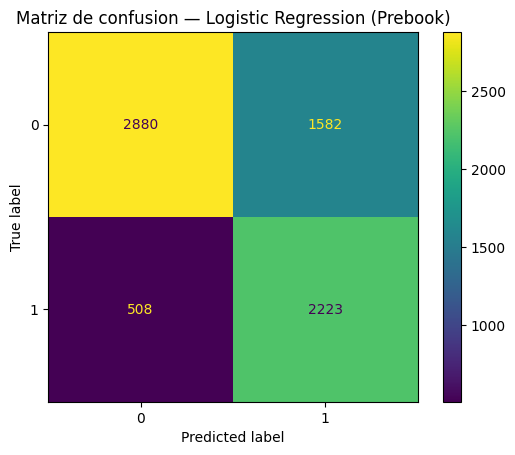

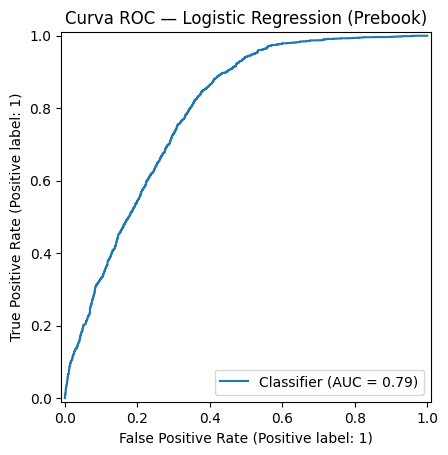

In [23]:
y_pred = model_lr.predict(X_test)
y_proba = model_lr.predict_proba(X_test)[:, 1]

print('Accuracy :', metrics.accuracy_score(y_test, y_pred))
print('Precision:', metrics.precision_score(y_test, y_pred, zero_division=0))
print('Recall   :', metrics.recall_score(y_test, y_pred, zero_division=0))
print('F1       :', metrics.f1_score(y_test, y_pred, zero_division=0))
print('ROC-AUC  :', metrics.roc_auc_score(y_test, y_proba))
print('\nReporte:')
print(metrics.classification_report(y_test, y_pred, zero_division=0))

cm = metrics.confusion_matrix(y_test, y_pred)
metrics.ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title('Matriz de confusion — Logistic Regression (Prebook)')
plt.show()

metrics.RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('Curva ROC — Logistic Regression (Prebook)')
plt.show()

## 10. Coeficientes (interpretacion de influencia)


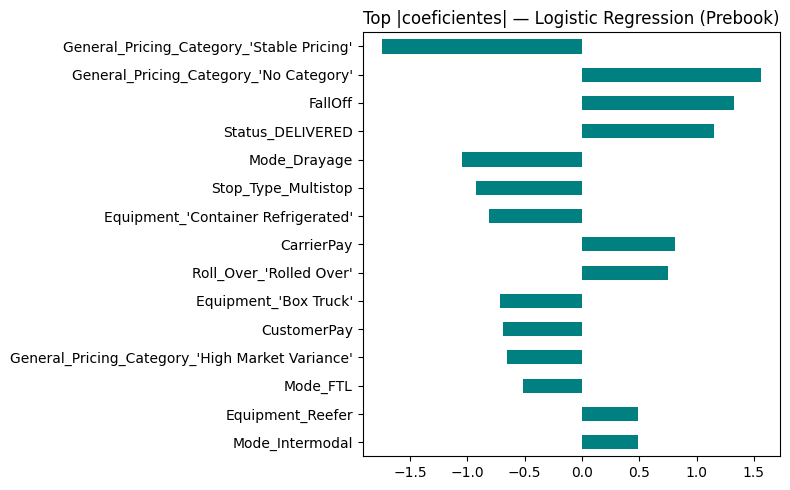

,0
General_Pricing_Category_'Stable Pricing',-1.747931
General_Pricing_Category_'No Category',1.562062
FallOff,1.322223
Status_DELIVERED,1.153689
Mode_Drayage,-1.046317
Stop_Type_Multistop,-0.920891
Equipment_'Container Refrigerated',-0.815162
CarrierPay,0.814440
Roll_Over_'Rolled Over',0.753947
Equipment_'Box Truck',-0.719216


In [24]:
coef = pd.Series(model_lr.coef_.ravel(), index=X_train.columns).sort_values(key=abs, ascending=False)
coef.head(15).iloc[::-1].plot(kind='barh', figsize=(8, 5), color='teal')
plt.title('Top |coeficientes| — Logistic Regression (Prebook)')
plt.tight_layout()
plt.show()
coef.head(15)

## 11. Validacion cruzada estratificada (10 folds)


In [25]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ('accuracy', 'precision', 'recall', 'f1', 'roc_auc')
model_cv = LogisticRegression(
    max_iter=500, class_weight='balanced', solver='lbfgs', random_state=42
)
scores = cross_validate(
    model_cv, x, y, cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1
)
scores_df = pd.DataFrame(scores)
scores_df

,fit_time,score_time,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1,test_roc_auc,train_roc_auc
0,0.362874,0.022710,0.705588,0.704547,0.578907,0.578438,0.825467,0.817483,0.680543,0.677493,0.787125,0.786545
1,0.322476,0.026167,0.696414,0.704639,0.570875,0.578497,0.809001,0.817849,0.669391,0.677659,0.783025,0.787183
2,0.188145,0.024484,0.713928,0.703017,0.589172,0.577029,0.813187,0.815674,0.683287,0.675905,0.787454,0.786654
3,0.261289,0.024974,0.701418,0.704037,0.574387,0.578033,0.823077,0.816528,0.676603,0.676887,0.790258,0.786217
4,0.267299,0.024034,0.705588,0.701812,0.577508,0.575528,0.835165,0.817627,0.682839,0.675542,0.794072,0.785897
5,0.311637,0.027183,0.714226,0.702289,0.587549,0.576050,0.829670,0.817383,0.687927,0.675818,0.798174,0.785237
6,0.287595,0.023502,0.699207,0.704977,0.574941,0.578707,0.796703,0.819458,0.667895,0.678355,0.781812,0.787400
7,0.311756,0.025805,0.695870,0.704931,0.569884,0.579011,0.810989,0.816284,0.669388,0.677473,0.775961,0.788293
8,0.313841,0.023816,0.702128,0.704607,0.576562,0.578416,0.810989,0.818481,0.673973,0.677820,0.786888,0.786805
9,0.222894,0.014506,0.697121,0.705255,0.571429,0.579170,0.808791,0.817993,0.669700,0.678170,0.775881,0.787734


## 12. Resumen CV


In [26]:
resumen = pd.DataFrame({
    'mean_test': [
        scores_df['test_accuracy'].mean(), scores_df['test_precision'].mean(),
        scores_df['test_recall'].mean(), scores_df['test_f1'].mean(),
        scores_df['test_roc_auc'].mean(),
    ],
    'std_test': [
        scores_df['test_accuracy'].std(), scores_df['test_precision'].std(),
        scores_df['test_recall'].std(), scores_df['test_f1'].std(),
        scores_df['test_roc_auc'].std(),
    ],
    'mean_train': [
        scores_df['train_accuracy'].mean(), scores_df['train_precision'].mean(),
        scores_df['train_recall'].mean(), scores_df['train_f1'].mean(),
        scores_df['train_roc_auc'].mean(),
    ],
}, index=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
print('Resumen CV 10-fold — Logistic Regression / Prebook')
resumen.round(4)

Resumen CV 10-fold — Logistic Regression / Prebook


,mean_test,std_test,mean_train
Accuracy,0.7031,0.0067,0.7040
Precision,0.5771,0.0066,0.5779
Recall,0.8163,0.0117,0.8175
F1,0.6762,0.0071,0.6771
ROC-AUC,0.7861,0.0072,0.7868
